In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
pwd

'C:\\Users\\Fathima'

In [6]:
cd downloads

C:\Users\Fathima\downloads


In [7]:
cd Machine Learning

C:\Users\Fathima\downloads\Machine Learning


In [8]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
def replace_outliers(dataframe,feature):
    q1=dataframe[feature].quantile(0.25)
    q3=dataframe[feature].quantile(0.75)
    iqr=q3-q1
    lower_range=q1-1.5*iqr
    upper_range=q3+1.5*iqr
    dataframe[feature]=np.where(dataframe[feature]<lower_range,lower_range,dataframe[feature])  #----np.where(condition,true,false)
    dataframe[feature]=np.where(dataframe[feature]>upper_range,upper_range,dataframe[feature])
replace_outliers(df,'oldpeak')
replace_outliers(df,'trestbps')
replace_outliers(df,'fbs')
replace_outliers(df,'thalach')
replace_outliers(df,'ca')
replace_outliers(df,'thal')

<Axes: >

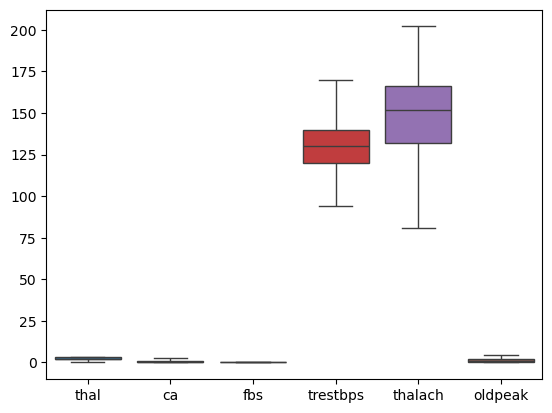

In [11]:
sns.boxplot(data=df[['thal','ca','fbs','trestbps','thalach','oldpeak']])

In [12]:
x=df[['cp','thalach','exang','oldpeak','slope','ca','thal','age','sex','chol','fbs','restecg','trestbps']]
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

target
0    423
1    423
Name: count, dtype: int64

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
accuracy = rf_model.score(x_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9853658536585366


In [18]:
scaler=StandardScaler()
x_train_sm=scaler.fit_transform(x_sm)
x_test_sm=scaler.transform(x_test)
model_sm= RandomForestClassifier()
model_sm.fit(x_train_sm,y_sm)
y_cap=model_sm.predict(x_test_sm)

sm = classification_report(y_test, y_cap, target_names=["0", "1"])
print("\nClassification Report:")
print(sm)


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}
rf = RandomForestClassifier()
rand_search = RandomizedSearchCV(rf, param_distributions = param_dist,n_iter=5, cv=5,verbose=1, n_jobs=-1)
rand_search.fit(x_train, y_train)
print("Best Hyperparameters:")
print(rand_search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters:
{'max_depth': 11, 'n_estimators': 407}
